In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data-export (1).csv", skiprows=1)
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024041723,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024041718,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024041720,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


In [3]:
print(df.info())
print("\n")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nColumn names:", df.columns.tolist())
print("\nTraffic sources:", df['Session primary channel group (Default channel group)'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Session primary channel group (Default channel group)  3182 non-null   object 
 1   Date + hour (YYYYMMDDHH)                               3182 non-null   int64  
 2   Users                                                  3182 non-null   int64  
 3   Sessions                                               3182 non-null   int64  
 4   Engaged sessions                                       3182 non-null   int64  
 5   Average engagement time per session                    3182 non-null   float64
 6   Engaged sessions per user                              3182 non-null   float64
 7   Events per session                                     3182 non-null   float64
 8   Engagement rate                                 

In [4]:
df.columns = df.columns.str.strip()

df['Date + hour (YYYYMMDDHH)'] = pd.to_datetime(
    df['Date + hour (YYYYMMDDHH)'], format='%Y%m%d%H')

df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

print("Cleaned! Shape:", df.shape)
df.head()

Cleaned! Shape: (3182, 10)


,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


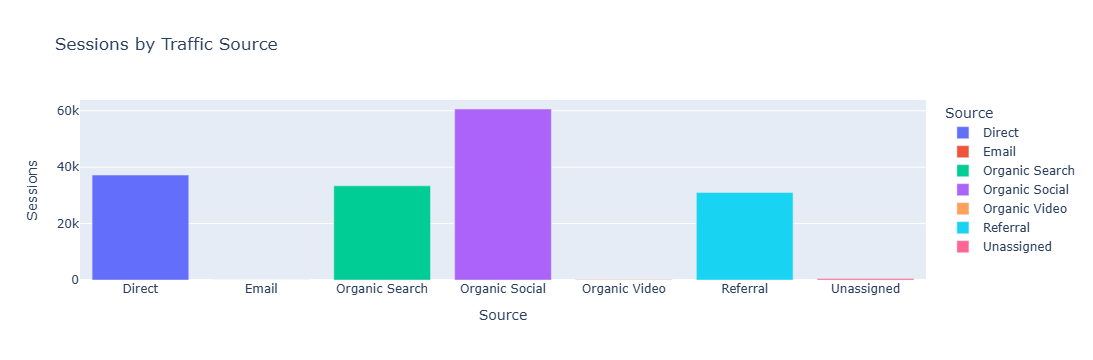

In [5]:
source_df = df.groupby('Session primary channel group (Default channel group)').agg({
    'Sessions': 'sum',
    'Users': 'sum',
    'Engaged sessions': 'sum',
    'Engagement rate': 'mean'
}).reset_index()

source_df.columns = ['Source','Sessions','Users','Engaged Sessions','Avg Engagement Rate']

import plotly.express as px
fig = px.bar(source_df, x='Source', y='Sessions',
             color='Source', title='Sessions by Traffic Source')
fig.show()

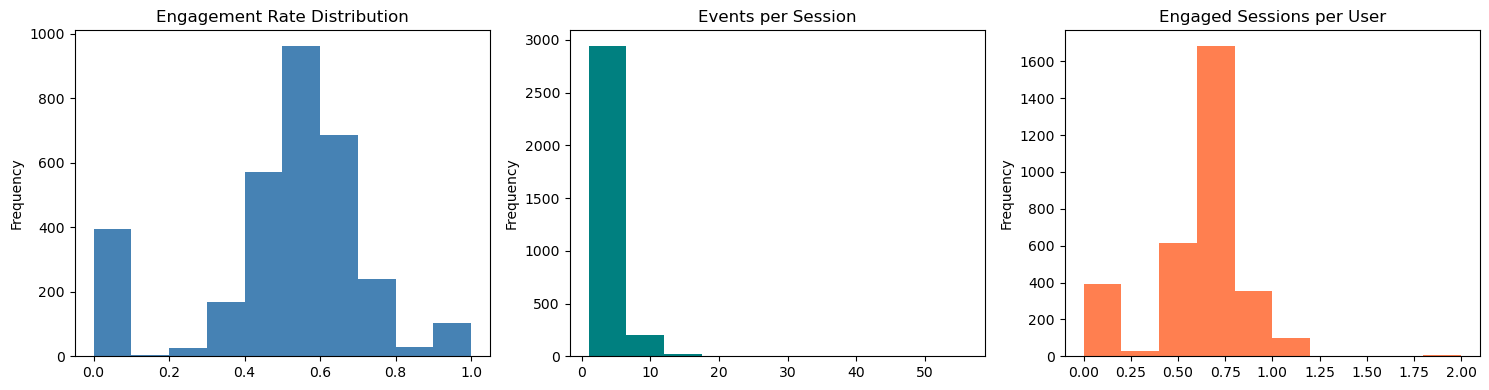

Avg Engagement Rate: 0.503
Avg Events per Session: 4.68


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Engagement rate'].plot(kind='hist', ax=axes[0], 
    title='Engagement Rate Distribution', color='steelblue')

df['Events per session'].plot(kind='hist', ax=axes[1], 
    title='Events per Session', color='teal')

df['Engaged sessions per user'].plot(kind='hist', ax=axes[2], 
    title='Engaged Sessions per User', color='coral')

plt.tight_layout()
plt.show()

print("Avg Engagement Rate:", round(df['Engagement rate'].mean(), 3))
print("Avg Events per Session:", round(df['Events per session'].mean(), 2))

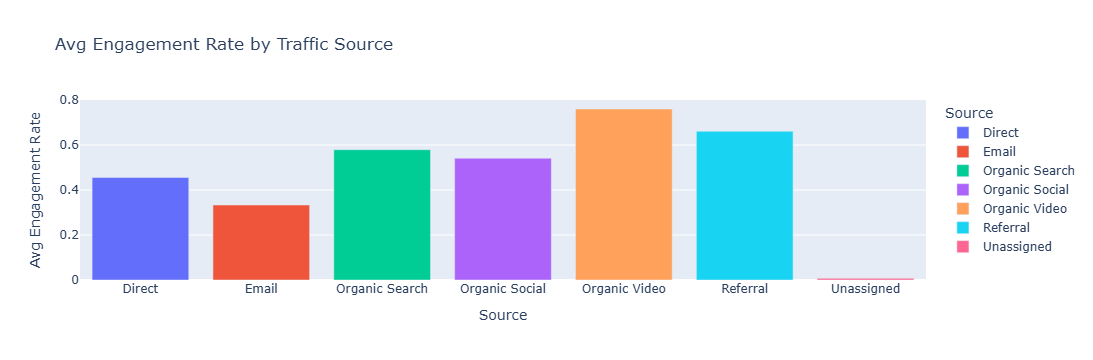


Top sources by engagement:
           Source  Sessions  Users  Engaged Sessions  Avg Engagement Rate  \
4   Organic Video       141    123               109             0.760000   
5        Referral     30990  26774             20653             0.660882   
2  Organic Search     33372  28387             19425             0.578906   
3  Organic Social     60627  47572             32697             0.541180   
0          Direct     37203  30042             17243             0.455723   
1           Email         3      2                 1             0.333333   
6      Unassigned       559    540                 4             0.007514   

   Engagement Score  
4             77.30  
5             66.64  
2             58.21  
3             53.93  
0             46.35  
1             33.33  
6              0.72  


In [7]:
source_df['Engagement Score'] = (
    source_df['Engaged Sessions'] / source_df['Sessions'] * 100
).round(2)

fig2 = px.bar(source_df, x='Source', y='Avg Engagement Rate',
              color='Source', title='Avg Engagement Rate by Traffic Source')
fig2.show()

print("\nTop sources by engagement:")
print(source_df.sort_values('Avg Engagement Rate', ascending=False))

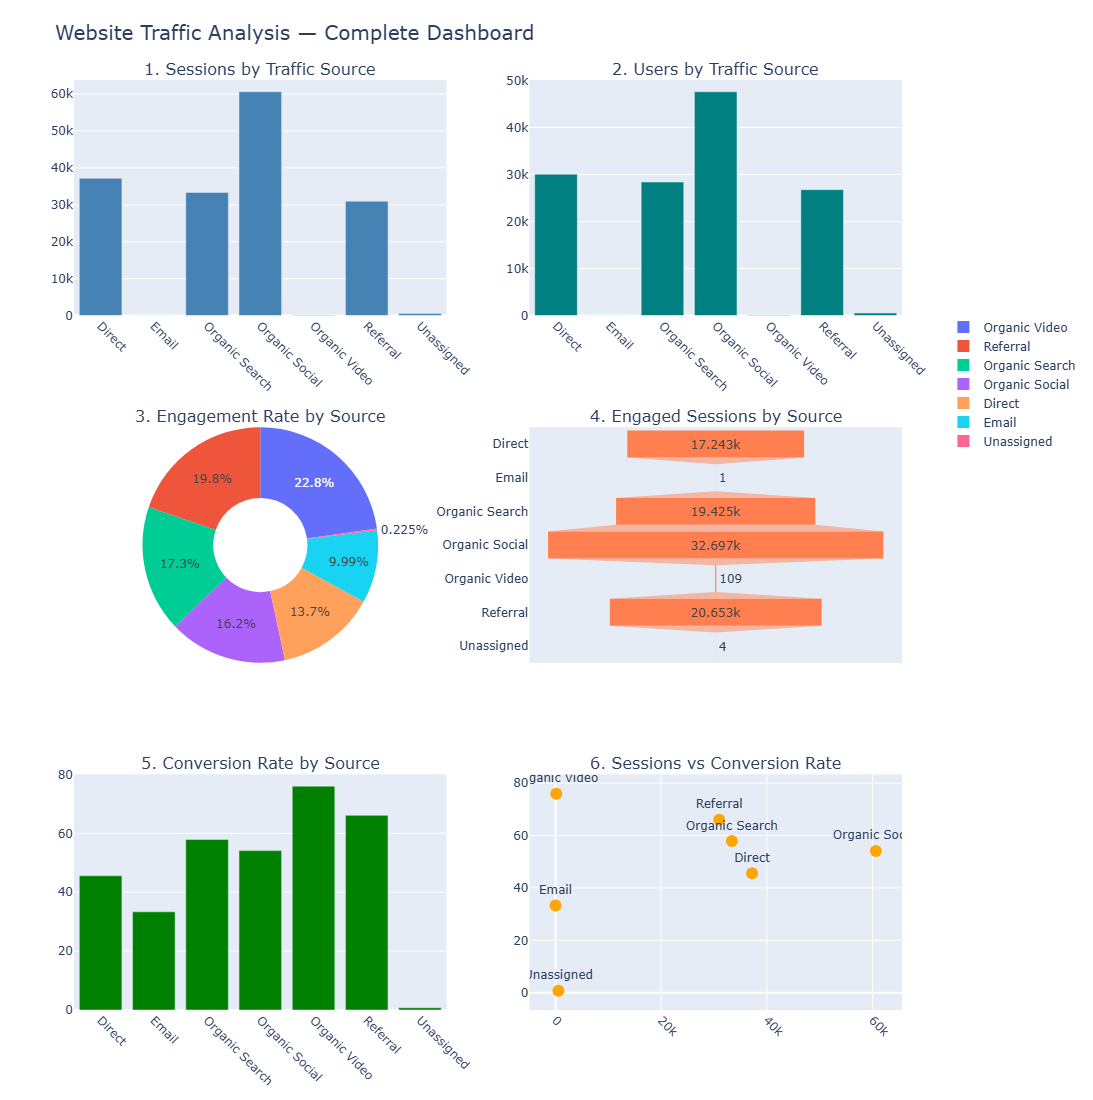

In [16]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        '1. Sessions by Traffic Source',
        '2. Users by Traffic Source',
        '3. Engagement Rate by Source',
        '4. Engaged Sessions by Source',
        '5. Conversion Rate by Source',
        '6. Sessions vs Conversion Rate'
    ),
    specs=[
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "pie"}, {"type": "funnel"}],
        [{"type": "bar"}, {"type": "scatter"}]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# Chart 1 - Sessions (Bar)
fig.add_trace(go.Bar(
    x=source_df['Source'],
    y=source_df['Sessions'],
    name='Sessions',
    marker_color='steelblue',
    showlegend=False), row=1, col=1)

# Chart 2 - Users (Bar)
fig.add_trace(go.Bar(
    x=source_df['Source'],
    y=source_df['Users'],
    name='Users',
    marker_color='teal',
    showlegend=False), row=1, col=2)

# Chart 3 - Engagement Rate (Donut)
fig.add_trace(go.Pie(
    labels=source_df['Source'],
    values=source_df['Avg Engagement Rate'],
    hole=0.4,
    name='Eng Rate',
    showlegend=True), row=2, col=1)

# Chart 4 - Engaged Sessions (Funnel)
fig.add_trace(go.Funnel(
    y=source_df['Source'],
    x=source_df['Engaged Sessions'],
    name='Eng Sessions',
    marker_color='coral',
    showlegend=False), row=2, col=2)

# Chart 5 - Conversion Rate (Bar)
fig.add_trace(go.Bar(
    x=top['Source'],
    y=top['Conversion Rate'],
    name='Conversion Rate',
    marker_color='green',
    showlegend=False), row=3, col=1)

# Chart 6 - Sessions vs Conversion (Scatter)
fig.add_trace(go.Scatter(
    x=top['Sessions'],
    y=top['Conversion Rate'],
    mode='markers+text',
    text=top['Source'],
    textposition='top center',
    name='Sess vs Conv',
    marker=dict(size=12, color='orange'),
    showlegend=False), row=3, col=2)

fig.update_layout(
    height=1100,
    width=1000,
    title_text='Website Traffic Analysis — Complete Dashboard',
    title_font_size=20,
    legend=dict(
        orientation='v',
        x=1.05,
        y=0.75
    ),
    margin=dict(t=80, b=60, l=60, r=150)
)

fig.update_xaxes(tickangle=45)

fig.show()